# Predicción del éxito de atracciones turísticas

En esta práctica construiremos un modelo de Deep Learning que combina:

1. **Imágenes** del punto de interés turístico.
2. **Metadatos estructurados** como coordenadas, categorías, tags, tier y experiencia.

El objetivo final es predecir si un POI tendrá:

```text
0 = engagement bajo
1 = engagement alto
```

In [1]:
# ============================================================
# 0. Preparación de archivos en Google Colab

from pathlib import Path
import os
import sys
import zipfile

IN_COLAB = "google.colab" in sys.modules
BASE_DIR = Path("/content") if IN_COLAB else Path(".").resolve()
os.chdir(BASE_DIR)

print(f"Directorio de trabajo: {Path.cwd()}")
print(f"¿Estoy en Google Colab?: {IN_COLAB}")

def localizar_archivo(nombre, carpeta_base=BASE_DIR):
    """Busca un archivo por nombre dentro del directorio de trabajo."""
    coincidencias = list(Path(carpeta_base).rglob(nombre))
    return coincidencias[0] if coincidencias else None

CSV_PATH = localizar_archivo("poi_dataset.csv")
IMAGE_ZIP_PATH = localizar_archivo("data_main.zip")

if IN_COLAB and (CSV_PATH is None or IMAGE_ZIP_PATH is None):
    from google.colab import files

    print("\nSube ahora uno de estos casos:")
    print("  A) practica_dl_poi_colab.zip")
    print("  B) poi_dataset.csv + data_main.zip")

    uploaded = files.upload()

    for filename in uploaded.keys():
        filename_path = Path(filename)
        if filename_path.suffix.lower() == ".zip" and filename_path.name != "data_main.zip":
            print(f"Extrayendo paquete de proyecto: {filename_path}")
            with zipfile.ZipFile(filename_path, "r") as z:
                z.extractall(BASE_DIR)

CSV_PATH = localizar_archivo("poi_dataset.csv")
IMAGE_ZIP_PATH = localizar_archivo("data_main.zip")

print(f"\nCSV encontrado en: {CSV_PATH}")
print(f"ZIP de imágenes encontrado en: {IMAGE_ZIP_PATH}")

DATA_MAIN_DIR = BASE_DIR / "data_main"
if not DATA_MAIN_DIR.exists():
    print("\nExtrayendo imágenes...")
    with zipfile.ZipFile(IMAGE_ZIP_PATH, "r") as z:
        z.extractall(BASE_DIR)
else:
    print("\nLa carpeta data_main ya existe. No se vuelve a extraer.")

assert DATA_MAIN_DIR.exists(), "No se pudo crear/encontrar la carpeta data_main."
print(f"Carpeta de imágenes preparada en: {DATA_MAIN_DIR}")

Directorio de trabajo: /content
¿Estoy en Google Colab?: True

Sube ahora uno de estos casos:
  A) practica_dl_poi_colab.zip
  B) poi_dataset.csv + data_main.zip


Saving poi_dataset.csv to poi_dataset.csv
Saving data_main.zip to data_main.zip

CSV encontrado en: /content/poi_dataset.csv
ZIP de imágenes encontrado en: /content/data_main.zip

Extrayendo imágenes...
Carpeta de imágenes preparada en: /content/data_main


In [2]:
# ============================================================
# 1. Imports y semillas

import random
import ast
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import joblib

import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga inicial

El dataset contiene:

- `id`: identificador único del POI.
- `name`: nombre del POI.
- `shortDescription`: descripción breve.
- `categories`: lista de categorías.
- `tier`, `locationLon`, `locationLat`, `xps`: metadatos numéricos.
- `tags`: etiquetas del POI.
- `Visits`, `Likes`, `Dislikes`, `Bookmarks`: métricas de interacción.
- `main_image_path`: ruta relativa de la imagen principal.



In [3]:
# ============================================================
# 2. Carga del CSV

df_raw = pd.read_csv(CSV_PATH)

print("Dimensiones del dataset original:", df_raw.shape)
display(df_raw.head())

print("\nTipos de datos:")
display(df_raw.dtypes)

print("\nValores nulos por columna:")
display(df_raw.isna().sum().sort_values(ascending=False))

Dimensiones del dataset original: (1569, 14)


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,La Galería Fran Reus es un espacio dedicado a ...,"['Escultura', 'Pintura']",1,2.642262,39.572694,[],500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,"El Convento de San Plácido en Madrid, fundado ...","['Patrimonio', 'Historia']",1,-3.704467,40.423037,[],500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,"El Instituto Geológico y Minero de España, sit...","['Ciencia', 'Patrimonio']",2,-3.699694,40.442045,[],250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,"Margarita Gil Roësset, escultora y poetisa esp...",['Cultura'],1,-3.691228,40.427256,[],500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,"El Museo del Traje de Madrid, fundado en 2004,...","['Patrimonio', 'Cultura']",1,-3.727822,40.439665,[],500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...



Tipos de datos:


,0
id,object
name,object
shortDescription,object
categories,object
tier,int64
locationLon,float64
locationLat,float64
tags,object
xps,int64
Visits,int64



Valores nulos por columna:


,0
id,0
name,0
shortDescription,0
categories,0
tier,0
locationLon,0
locationLat,0
tags,0
xps,0
Visits,0


## 3. Limpieza inicial y tratamiento de duplicados

Al revisar el dataset se observa que puede haber varios registros con el mismo `id`.  
Como cada POI tiene una única imagen principal, si dejamos duplicados podríamos tener la misma imagen en entrenamiento y test, generando **data leakage**.

Para evitarlo:

1. Agrupamos por `id`.
2. Conservamos los metadatos fijos del primer registro.
3. Unimos las listas de categorías y tags.
4. Calculamos la media de las métricas de engagement para cada POI.

Así tendremos una fila por POI.

In [4]:
# ============================================================
# 3. Funciones de limpieza y agregación


def parse_list_string(value):
    if pd.isna(value):
        return []

    if isinstance(value, list):
        return value

    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
        return []
    except Exception:
        return []


def union_lists(series):

    result = []
    seen = set()

    for values in series:
        for value in values:
            if value not in seen:
                seen.add(value)
                result.append(value)

    return result


def aggregate_duplicate_pois(df):

    df = df.copy()
    df["categories_list"] = df["categories"].apply(parse_list_string)
    df["tags_list"] = df["tags"].apply(parse_list_string)

    aggregation = {
        "name": "first",
        "shortDescription": "first",
        "tier": "first",
        "locationLon": "first",
        "locationLat": "first",
        "xps": "first",
        "Visits": "mean",
        "Likes": "mean",
        "Dislikes": "mean",
        "Bookmarks": "mean",
        "main_image_path": "first",
        "categories_list": union_lists,
        "tags_list": union_lists,
    }

    df_agg = df.groupby("id", as_index=False).agg(aggregation)
    return df_agg


df = aggregate_duplicate_pois(df_raw)

print("Filas originales:", len(df_raw))
print("POIs únicos después de agrupar:", len(df))
print("Duplicados eliminados/agregados:", len(df_raw) - len(df))

display(df.head())

Filas originales: 1569
POIs únicos después de agrupar: 1492
Duplicados eliminados/agregados: 77


,id,name,shortDescription,tier,locationLon,locationLat,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path,categories_list,tags_list
0,002b3c1f-37f0-4d36-84d4-2d7132f83fe7,Casa-Museo de la Inquisición de Garganta la Olla,¡Visita la Casa-Museo de la Inquisición! Un vi...,1,-5.776669,40.111279,1000,10010.0,865.0,3099.0,118.0,data_main/002b3c1f-37f0-4d36-84d4-2d7132f83fe7...,"[Patrimonio, Cultura, Historia, Misterio]","[Museos, Instalación, Inquisición, Edificios, ..."
1,005fe23a-7f9e-4a57-a24a-1e9a6f1c1702,Real Basílica de San Francisco el Grande,"La Real Basílica de San Francisco el Grande, j...",2,-3.714472,40.410457,250,10011.0,8384.0,136.0,2275.0,data_main/005fe23a-7f9e-4a57-a24a-1e9a6f1c1702...,"[Arquitectura, Patrimonio]",[s.XVIII]
2,00761a42-1b02-42f3-b2b2-211ffd985118,Puerta de Toledo,¡Visita la Puerta de Toledo! Un arco triunfal ...,1,-3.711620,40.406714,800,10006.0,8359.0,146.0,2151.0,data_main/00761a42-1b02-42f3-b2b2-211ffd985118...,"[Cultura, Arquitectura, Historia]","[Arquitectura neoclásica, Madrid, Centro, Rest..."
3,0089bb20-c132-496c-b215-1986fcfa9d4b,Cuesta de los ciegos,La Cuesta de los Ciegos es una escalera empedr...,3,-3.714567,40.412984,150,10007.0,8398.0,137.0,2487.0,data_main/0089bb20-c132-496c-b215-1986fcfa9d4b...,"[Arquitectura, Historia]",[]
4,00f483bf-a5a2-4009-bc67-b9f3f2e73488,Escultura de AENA,"Admira la Escultura AENA, un símbolo de modern...",2,-3.652625,40.450756,600,10010.0,353.0,3901.0,82.0,data_main/00f483bf-a5a2-4009-bc67-b9f3f2e73488...,"[Historia, Arquitectura, Escultura]","[Madrid, Arte, Cultura, Historia, Urbanismo, E..."


In [5]:
# ============================================================
# 3.1 Validación de rutas de imágenes

def to_absolute_image_path(relative_path):

    return str((BASE_DIR / relative_path).resolve())

df["image_path_abs"] = df["main_image_path"].apply(to_absolute_image_path)
df["image_exists"] = df["image_path_abs"].apply(lambda p: Path(p).exists())

print("Imágenes existentes:")
display(df["image_exists"].value_counts())

# Nos quedamos solo con POIs que tienen imagen disponible.
df = df[df["image_exists"]].copy().reset_index(drop=True)

print("Dataset final tras validar imágenes:", df.shape)

Imágenes existentes:


,count
image_exists,
True,1492


Dataset final tras validar imágenes: (1492, 16)


## 4. Análisis exploratorio de datos

En esta sección revisamos:

- Distribución de métricas de interacción.
- Categorías más frecuentes.
- Tags más frecuentes.
- Algunas imágenes de ejemplo.

Este análisis sirve para entender los datos antes de entrenar el modelo.

In [6]:
# ============================================================
# 4.1 Resumen numérico

numeric_summary_cols = [
    "tier", "locationLon", "locationLat", "xps",
    "Visits", "Likes", "Dislikes", "Bookmarks"
]

display(df[numeric_summary_cols].describe().T)

print("Número de categorías únicas:", len(set(x for values in df["categories_list"] for x in values)))
print("Número de tags únicos:", len(set(x for values in df["tags_list"] for x in values)))

,count,mean,std,min,25%,50%,75%,max
tier,1492.0,1.565684,0.642014,1.000000,1.000000,1.000000,2.000000,4.000000
locationLon,1492.0,-2.066378,20.096639,-121.951049,-3.725086,-3.700257,-3.679335,158.333118
locationLat,1492.0,39.850083,8.365356,-62.940930,40.412077,40.421421,40.460085,65.706572
xps,1492.0,740.516086,225.277685,0.000000,600.000000,700.000000,1000.000000,1000.000000
Visits,1492.0,10011.913695,5.421825,10001.000000,10008.000000,10011.000000,10015.000000,10038.000000
Likes,1492.0,3587.443607,4784.020524,100.000000,450.000000,1282.500000,6467.750000,26425.000000
Dislikes,1492.0,2555.199524,2231.401859,52.000000,956.250000,2734.000000,3424.000000,10999.000000
Bookmarks,1492.0,964.850286,1448.093127,50.000000,116.000000,303.000000,1264.500000,8157.000000


Número de categorías únicas: 12
Número de tags únicos: 2935


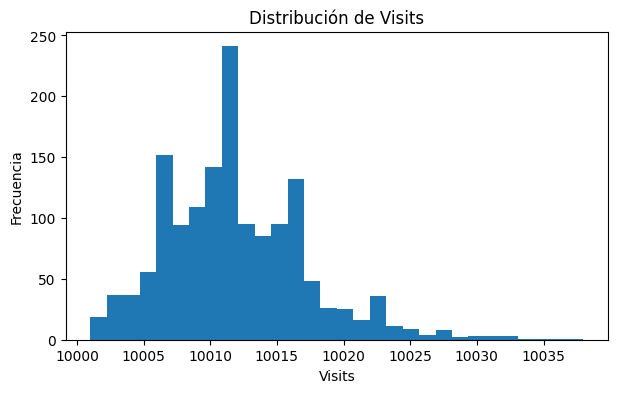

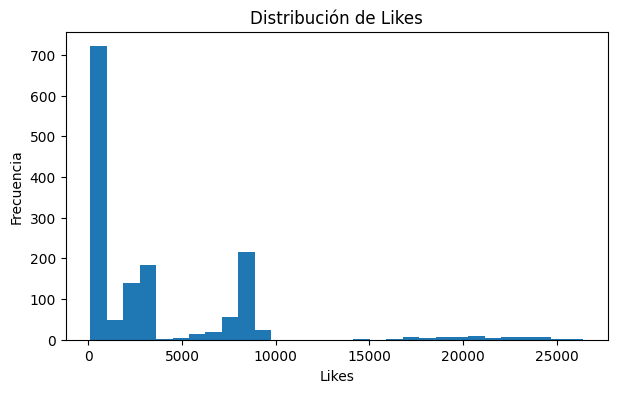

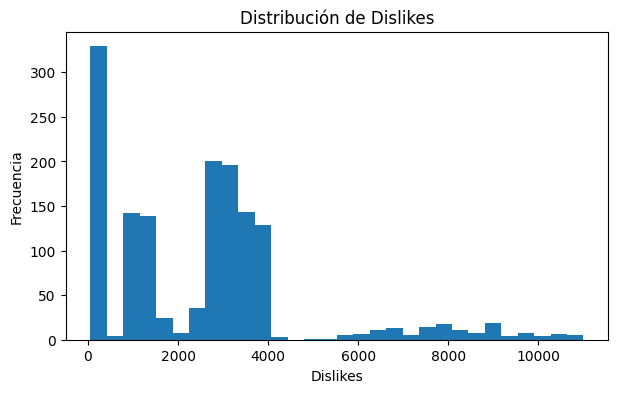

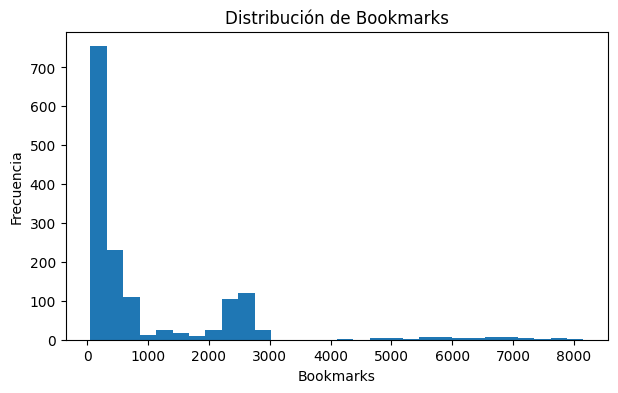

In [7]:
# ============================================================
# 4.2 Distribuciones de métricas de engagement

engagement_cols = ["Visits", "Likes", "Dislikes", "Bookmarks"]

for col in engagement_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

,category,count
0,Historia,1230
1,Cultura,958
2,Arquitectura,643
3,Patrimonio,574
4,Escultura,474
5,Misterio,311
6,Ciencia,123
7,Ocio,73
8,Pintura,47
9,Naturaleza,43


,tag,count
0,Historia,802
1,Madrid,700
2,Cultura,583
3,Arquitectura,398
4,Patrimonio,353
5,Arte,329
6,Escultura,328
7,Estatua,269
8,Monumento,166
9,Naturaleza,150


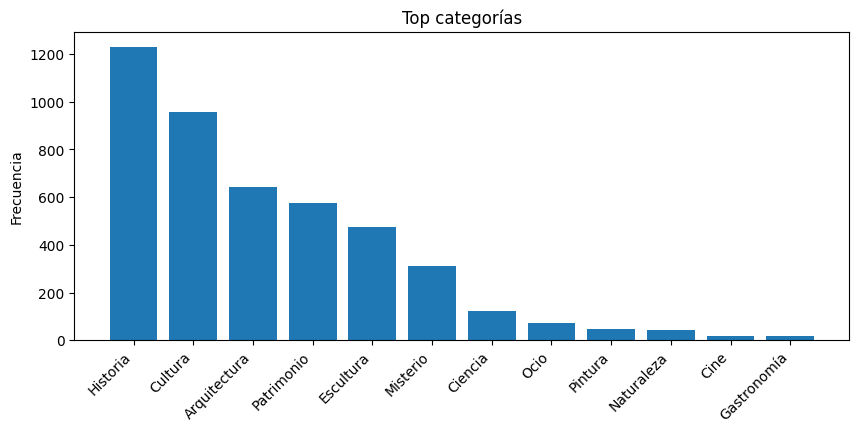

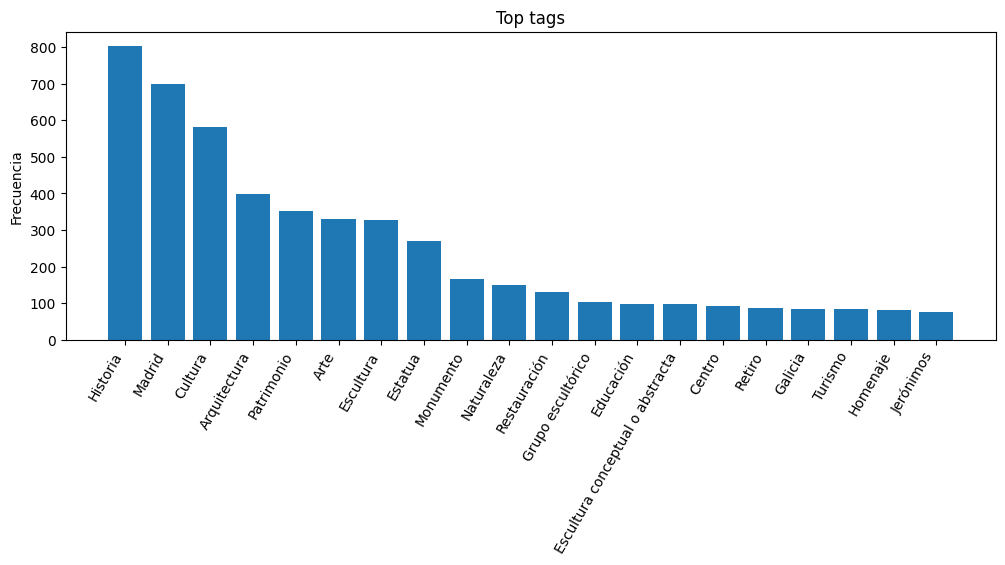

In [8]:
# ============================================================
# 4.3 Categorías y tags más frecuentes

category_counter = Counter(x for values in df["categories_list"] for x in values)
tag_counter = Counter(x for values in df["tags_list"] for x in values)

top_categories = pd.DataFrame(category_counter.most_common(15), columns=["category", "count"])
top_tags = pd.DataFrame(tag_counter.most_common(20), columns=["tag", "count"])

display(top_categories)
display(top_tags)

plt.figure(figsize=(10, 4))
plt.bar(top_categories["category"], top_categories["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top categorías")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(top_tags["tag"], top_tags["count"])
plt.xticks(rotation=60, ha="right")
plt.title("Top tags")
plt.ylabel("Frecuencia")
plt.show()

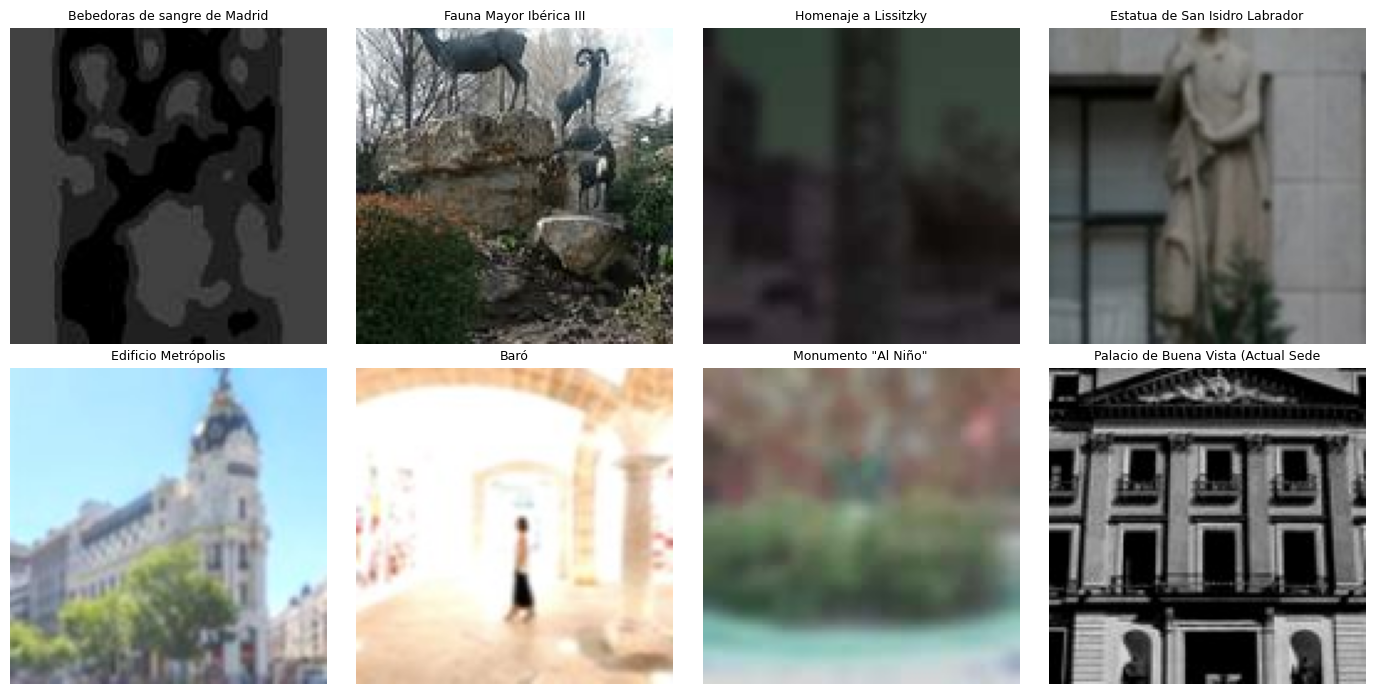

In [9]:
# ============================================================
# 4.4 Visualización de imágenes de ejemplo

sample_images = df.sample(n=min(8, len(df)), random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for ax, (_, row) in zip(axes, sample_images.iterrows()):
    img = Image.open(row["image_path_abs"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(row["name"][:35], fontsize=9)
    ax.axis("off")

for ax in axes[len(sample_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Creación de la variable objetivo: engagement alto / bajo

El dataset no trae una etiqueta directa llamada `engagement_alto`.  
Por eso construimos una métrica propia combinando:

- **Likes**: señal positiva fuerte.
- **Bookmarks**: señal positiva de interés futuro.
- **Visits**: señal positiva, pero con poco peso porque tiene poca variabilidad.
- **Dislikes**: señal negativa.

Primero aplicamos `log1p` para reducir el efecto de valores extremos.  
Después escalamos cada métrica entre 0 y 1.  
Finalmente creamos una puntuación:

```text
engagement_score =
    0.50 * likes_scaled
  + 0.30 * bookmarks_scaled
  + 0.10 * visits_scaled
  - 0.10 * dislikes_scaled
```

Luego usamos la mediana como umbral:

```text
engagement_label = 1 si engagement_score >= mediana
engagement_label = 0 si engagement_score < mediana
```

Esta decisión crea clases bastante equilibradas y facilita entrenar un clasificador binario.

Umbral de engagement usado: 0.26691538426516626

Distribución de clases:


,count
engagement_label,
bajo,746
alto,746


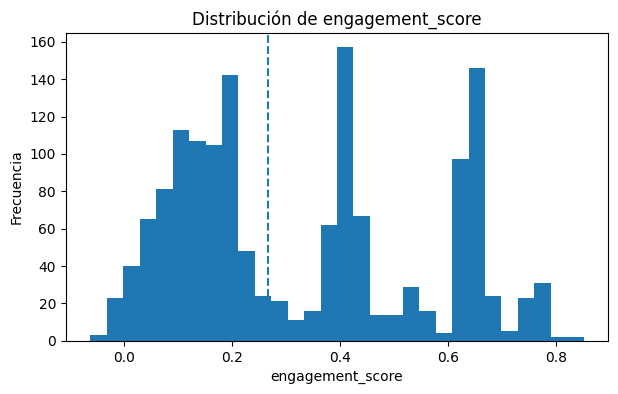

In [10]:
# ============================================================
# 5. Creación de engagement_score y engagement_label

def minmax_series(series):

    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return series * 0.0

    return (series - min_value) / (max_value - min_value)


def create_engagement_target(df):

    df = df.copy()

    for col in ["Visits", "Likes", "Dislikes", "Bookmarks"]:
        df[f"{col}_log"] = np.log1p(df[col].astype(float))
        df[f"{col}_scaled"] = minmax_series(df[f"{col}_log"])

    df["engagement_score"] = (
        0.50 * df["Likes_scaled"]
        + 0.30 * df["Bookmarks_scaled"]
        + 0.10 * df["Visits_scaled"]
        - 0.10 * df["Dislikes_scaled"]
    )

    threshold = df["engagement_score"].median()
    df["engagement_label"] = (df["engagement_score"] >= threshold).astype(int)

    return df, threshold


df, engagement_threshold = create_engagement_target(df)

print("Umbral de engagement usado:", engagement_threshold)
print("\nDistribución de clases:")
display(df["engagement_label"].value_counts().rename(index={0: "bajo", 1: "alto"}))

plt.figure(figsize=(7, 4))
plt.hist(df["engagement_score"], bins=30)
plt.axvline(engagement_threshold, linestyle="--")
plt.title("Distribución de engagement_score")
plt.xlabel("engagement_score")
plt.ylabel("Frecuencia")
plt.show()

## 6. División train / validation / test

Dividimos el dataset en:

- **Train:** para entrenar el modelo.
- **Validation:** para ajustar decisiones durante el entrenamiento.
- **Test:** para evaluar el modelo final en datos no vistos.



In [11]:
# ============================================================
# 6. División estratificada

train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["engagement_label"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_val_df["engagement_label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nDistribución de clases en train:")
display(train_df["engagement_label"].value_counts(normalize=True))

print("\nDistribución de clases en validation:")
display(val_df["engagement_label"].value_counts(normalize=True))

print("\nDistribución de clases en test:")
display(test_df["engagement_label"].value_counts(normalize=True))

Train: (954, 26)
Validation: (239, 26)
Test: (299, 26)

Distribución de clases en train:


,proportion
engagement_label,
0,0.5
1,0.5



Distribución de clases en validation:


,proportion
engagement_label,
1,0.502092
0,0.497908



Distribución de clases en test:


,proportion
engagement_label,
0,0.501672
1,0.498328


## 7. Preprocesamiento de metadatos

Para la rama tabular del modelo usaremos:

### Variables numéricas

- tier
- locationLon
- locationLat
- xps
- longitud del nombre
- longitud de la descripción
- número de categorías
- número de tags

### Variables categóricas

- Categorías del POI con codificación multi-hot.
- Top N tags más frecuentes en train con codificación multi-hot.


In [12]:
# ============================================================
# 7. Feature engineering tabular

def add_basic_text_features(df):

    df = df.copy()
    df["name_length"] = df["name"].fillna("").astype(str).str.len()
    df["description_length"] = df["shortDescription"].fillna("").astype(str).str.len()
    df["num_categories"] = df["categories_list"].apply(len)
    df["num_tags"] = df["tags_list"].apply(len)
    return df


train_df = add_basic_text_features(train_df)
val_df = add_basic_text_features(val_df)
test_df = add_basic_text_features(test_df)

numeric_feature_cols = [
    "tier",
    "locationLon",
    "locationLat",
    "xps",
    "name_length",
    "description_length",
    "num_categories",
    "num_tags",
]


def build_tabular_preprocessor(train_df, top_n_tags=50):

    scaler = StandardScaler()
    scaler.fit(train_df[numeric_feature_cols])

    category_encoder = MultiLabelBinarizer()
    category_encoder.fit(train_df["categories_list"])

    tag_counter = Counter(tag for tags in train_df["tags_list"] for tag in tags)
    top_tags = [tag for tag, _ in tag_counter.most_common(top_n_tags)]

    return {
        "scaler": scaler,
        "category_encoder": category_encoder,
        "top_tags": top_tags,
        "numeric_feature_cols": numeric_feature_cols,
    }


def transform_tags(df, top_tags):

    tag_to_idx = {tag: idx for idx, tag in enumerate(top_tags)}
    matrix = np.zeros((len(df), len(top_tags)), dtype=np.float32)

    for row_idx, tags in enumerate(df["tags_list"]):
        for tag in tags:
            if tag in tag_to_idx:
                matrix[row_idx, tag_to_idx[tag]] = 1.0

    return matrix


def transform_tabular_features(df, preprocessor):

    scaler = preprocessor["scaler"]
    category_encoder = preprocessor["category_encoder"]
    top_tags = preprocessor["top_tags"]

    X_num = scaler.transform(df[preprocessor["numeric_feature_cols"]]).astype(np.float32)
    X_cat = category_encoder.transform(df["categories_list"]).astype(np.float32)
    X_tags = transform_tags(df, top_tags).astype(np.float32)

    X = np.hstack([X_num, X_cat, X_tags]).astype(np.float32)

    feature_names = (
        preprocessor["numeric_feature_cols"]
        + [f"category__{c}" for c in category_encoder.classes_]
        + [f"tag__{t}" for t in top_tags]
    )

    return X, feature_names


preprocessor = build_tabular_preprocessor(train_df, top_n_tags=50)

X_train_tab, tabular_feature_names = transform_tabular_features(train_df, preprocessor)
X_val_tab, _ = transform_tabular_features(val_df, preprocessor)
X_test_tab, _ = transform_tabular_features(test_df, preprocessor)

y_train = train_df["engagement_label"].astype(np.float32).values
y_val = val_df["engagement_label"].astype(np.float32).values
y_test = test_df["engagement_label"].astype(np.float32).values

print("Shape X_train_tab:", X_train_tab.shape)
print("Shape X_val_tab:", X_val_tab.shape)
print("Shape X_test_tab:", X_test_tab.shape)
print("Número de features tabulares:", len(tabular_feature_names))

display(pd.DataFrame({"feature_name": tabular_feature_names}).head(20))

Shape X_train_tab: (954, 70)
Shape X_val_tab: (239, 70)
Shape X_test_tab: (299, 70)
Número de features tabulares: 70


,feature_name
0,tier
1,locationLon
2,locationLat
3,xps
4,name_length
5,description_length
6,num_categories
7,num_tags
8,category__Arquitectura
9,category__Ciencia


## 8. Dataset de imágenes con `tf.data`

Ahora construimos los datasets que alimentarán el modelo.

Cada ejemplo tendrá dos entradas:

```python
{
    "image_input": imagen,
    "tabular_input": metadatos
}
```

y una salida:

```python
engagement_label
```

In [13]:
# ============================================================
# 8. Dataset TensorFlow

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def make_paths(df):
    return df["image_path_abs"].astype(str).values


train_paths = make_paths(train_df)
val_paths = make_paths(val_df)
test_paths = make_paths(test_df)


def load_image_and_features(path, tabular_features, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    inputs = {
        "image_input": image,
        "tabular_input": tabular_features
    }

    return inputs, label


def make_dataset(paths, X_tabular, y, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, X_tabular.astype(np.float32), y.astype(np.float32))
    )

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image_and_features, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_paths, X_train_tab, y_train, training=True)
val_ds = make_dataset(val_paths, X_val_tab, y_val, training=False)
test_ds = make_dataset(test_paths, X_test_tab, y_test, training=False)

print(train_ds)

<_PrefetchDataset element_spec=({'image_input': TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), 'tabular_input': TensorSpec(shape=(None, 70), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


## 9. Arquitectura del modelo multimodal

El modelo tiene dos ramas:

### Rama visual

Procesa la imagen con una CNN sencilla.

### Rama tabular

Procesa los metadatos.

### Fusión

Se concatenan ambas ramas y se pasa por capas densas finales.  
La salida usa una neurona con `sigmoid`, porque es clasificación binaria.

In [14]:
# ============================================================
# 9. Construcción del modelo multimodal


def build_multimodal_model(tabular_input_dim, image_shape=(128, 128, 3)):
    # Rama visual
    # -------------------------
    image_input = layers.Input(shape=image_shape, name="image_input")

    augmentation = tf.keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
        ],
        name="data_augmentation"
    )

    x = augmentation(image_input)

    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)

    # Rama tabular
    # -------------------------
    tabular_input = layers.Input(shape=(tabular_input_dim,), name="tabular_input")

    t = layers.Dense(128, activation="relu")(tabular_input)
    t = layers.BatchNormalization()(t)
    t = layers.Dropout(0.30)(t)

    t = layers.Dense(64, activation="relu")(t)
    t = layers.Dropout(0.20)(t)

    # Fusión
    # -------------------------
    combined = layers.Concatenate(name="fusion_image_tabular")([x, t])

    z = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(combined)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.40)(z)

    z = layers.Dense(64, activation="relu")(z)
    z = layers.Dropout(0.25)(z)

    output = layers.Dense(1, activation="sigmoid", name="engagement_output")(z)

    model = Model(
        inputs={
            "image_input": image_input,
            "tabular_input": tabular_input
        },
        outputs=output,
        name="multimodal_poi_engagement_model"
    )

    return model


model = build_multimodal_model(tabular_input_dim=X_train_tab.shape[1])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

model.summary()

Model: "multimodal_poi_engagement_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 70)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      9,088 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 474,625 (1.81 MB)

 Trainable params: 473,153 (1.80 MB)

 Non-trainable params: 1,472 (5.75 KB)

## 10. Entrenamiento

Usaremos tres callbacks:

- **EarlyStopping**: detiene el entrenamiento si no mejora la validación.
- **ModelCheckpoint**: guarda el mejor modelo.
- **ReduceLROnPlateau**: reduce el learning rate si el modelo se estanca.

El objetivo no es conseguir un modelo perfecto, sino tener un pipeline completo, reproducible y razonado.

In [15]:
# ============================================================
# 10. Entrenamiento

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
]

EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.6331 - auc: 0.6781 - loss: 0.7338 - precision: 0.6508 - recall: 0.5744 - val_accuracy: 0.5105 - val_auc: 0.7387 - val_loss: 0.6926 - val_precision: 1.0000 - val_recall: 0.0250 - learning_rate: 0.0010
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.7212 - auc: 0.7834 - loss: 0.5894 - precision: 0.7249 - recall: 0.7128 - val_accuracy: 0.5816 - val_auc: 0.8229 - val_loss: 0.6543 - val_precision: 1.0000 - val_recall: 0.1667 - learning_rate: 0.0010
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7883 - auc: 0.8631 - loss: 0.4827 - precision: 0.7932 - recall: 0.7799 - val_accuracy: 0.7364 - val_auc: 0.7966 - val_loss: 0.5839 - val_precision: 0.7568 - val_recall: 0.7000 - learning_rate: 0.0010
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7935 - auc: 0.8799 - loss: 0.4638 - precision: 0.7893 - recall: 0.8008 - val_accuracy: 0.4979 - val_auc: 0.8626 - val_loss: 0.8285 - val_p

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
9,0.898323,0.966683,0.247352,0.895833,0.901468,0.564854,0.936800,0.825639,1.0,0.133333,0.000250
10,0.890985,0.964376,0.256111,0.894292,0.886792,0.552301,0.925455,0.874742,1.0,0.108333,0.000250
11,0.889937,0.964974,0.254790,0.894068,0.884696,0.552301,0.920028,0.874005,1.0,0.108333,0.000250
12,0.896226,0.972619,0.223922,0.909091,0.880503,0.627615,0.940126,0.703496,1.0,0.258333,0.000125
13,0.905660,0.966866,0.245901,0.912580,0.897275,0.677824,0.941492,0.584094,1.0,0.358333,0.000125


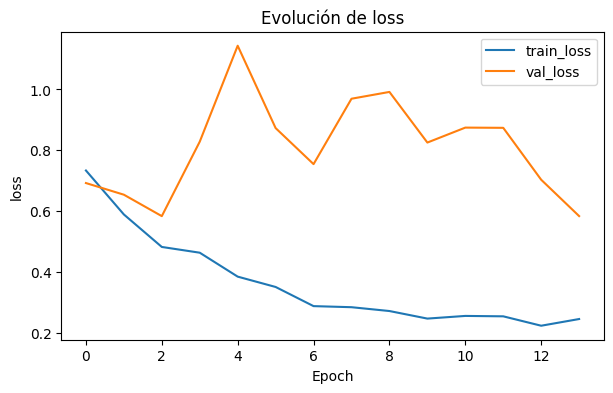

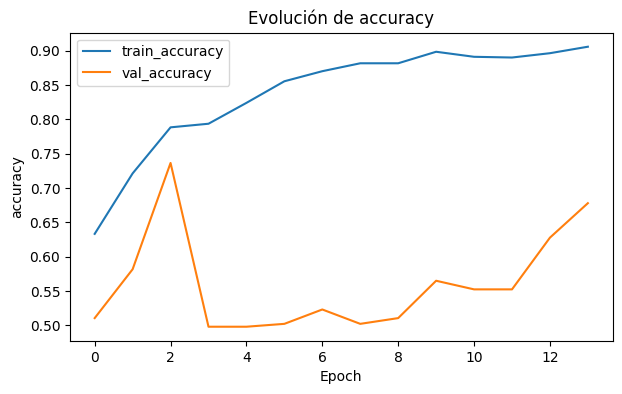

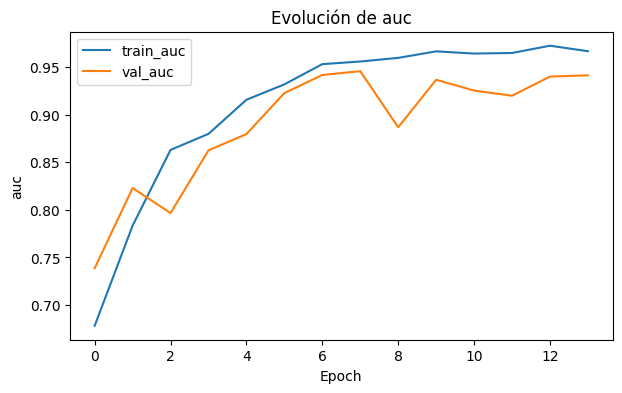

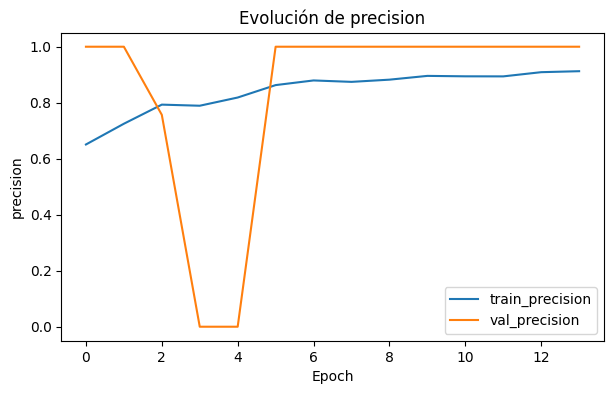

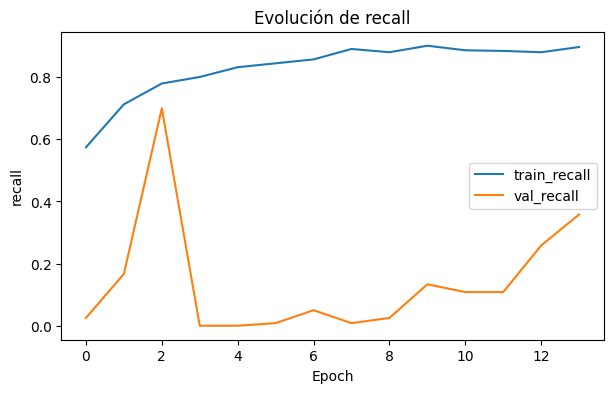

In [16]:
# ============================================================
# 10.1 Curvas de entrenamiento


history_df = pd.DataFrame(history.history)
display(history_df.tail())

def plot_metric(history_df, metric):
    plt.figure(figsize=(7, 4))
    plt.plot(history_df[metric], label=f"train_{metric}")

    val_metric = f"val_{metric}"
    if val_metric in history_df.columns:
        plt.plot(history_df[val_metric], label=val_metric)

    plt.title(f"Evolución de {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.show()


for metric in ["loss", "accuracy", "auc", "precision", "recall"]:
    if metric in history_df.columns:
        plot_metric(history_df, metric)

## 11. Evaluación en test

Evaluamos el modelo en datos no vistos.

Métricas importantes:

- **Accuracy:** porcentaje de aciertos.
- **Precision:** de los POIs predichos como alto engagement, cuántos realmente eran altos.
- **Recall:** de los POIs realmente altos, cuántos detectamos.
- **F1-score:** equilibrio entre precision y recall.
- **AUC:** capacidad de separación entre clases.

También comparamos contra un baseline simple.  
Como las clases están equilibradas, un clasificador aleatorio estaría alrededor de 0.50 de accuracy.

In [17]:
# ============================================================
# 11. Evaluación del modelo


test_metrics = model.evaluate(test_ds, return_dict=True, verbose=0)
display(pd.DataFrame([test_metrics]))

y_proba = model.predict(test_ds).ravel()
y_pred = (y_proba >= 0.5).astype(int)
y_true = y_test.astype(int)

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=["engagement_bajo", "engagement_alto"], digits=4))

metrics_summary = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_proba),
    "baseline_random_accuracy_aprox": 0.50,
    "baseline_majority_accuracy": max(np.mean(y_true), 1 - np.mean(y_true)),
}

display(pd.DataFrame([metrics_summary]).T.rename(columns={0: "valor"}))

,accuracy,auc,loss,precision,recall
0,0.511706,0.94906,0.93249,1.0,0.020134


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Classification report:
                 precision    recall  f1-score   support

engagement_bajo     0.5068    1.0000    0.6726       150
engagement_alto     1.0000    0.0201    0.0395       149

       accuracy                         0.5117       299
      macro avg     0.7534    0.5101    0.3561       299
   weighted avg     0.7526    0.5117    0.3571       299



,valor
accuracy,0.511706
precision,1.000000
recall,0.020134
f1,0.039474
roc_auc,0.949306
baseline_random_accuracy_aprox,0.500000
baseline_majority_accuracy,0.501672


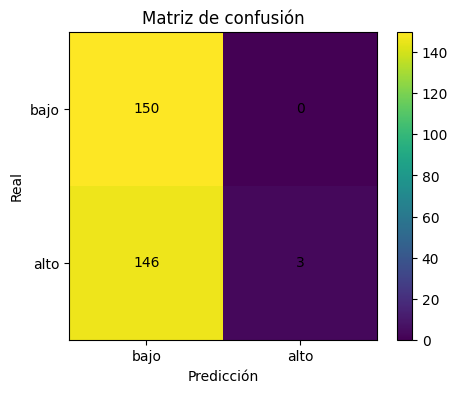

In [18]:
# ============================================================
# 11.1 Matriz de confusión


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], ["bajo", "alto"])
plt.yticks([0, 1], ["bajo", "alto"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 12. Análisis de errores

Revisar errores ayuda a entender qué está aprendiendo el modelo.

- **Falsos positivos:** el modelo predice engagement alto, pero era bajo.
- **Falsos negativos:** el modelo predice engagement bajo, pero era alto.

Este análisis es útil para proponer mejoras futuras.

Falsos positivos: 0
Falsos negativos: 146


,id,name,engagement_score,y_true,y_pred,prob_engagement_alto
1009,b0a3ab0b-600b-4f3c-b01d-97431a258581,Mojón de la antigua carretera de Brunete,0.223654,0,0,0.053282
815,8c7ccef7-1754-43ef-ba38-4504a8b26e2c,Escultura del Burrito,0.256769,0,0,0.002612
454,4b7590ca-882a-4d6a-8121-c483175d744c,Casón del Buen Retiro,0.463540,1,0,0.129886
51,08c43859-c439-4923-ae0f-86137de48ee7,Palacio de Lezcano o de O'Reilly,0.632830,1,0,0.140663
260,286220e3-3692-437d-b9d7-31c359c7bc40,La Mansión Winchester,0.208534,0,0,0.087344


No hay ejemplos para: Falsos positivos


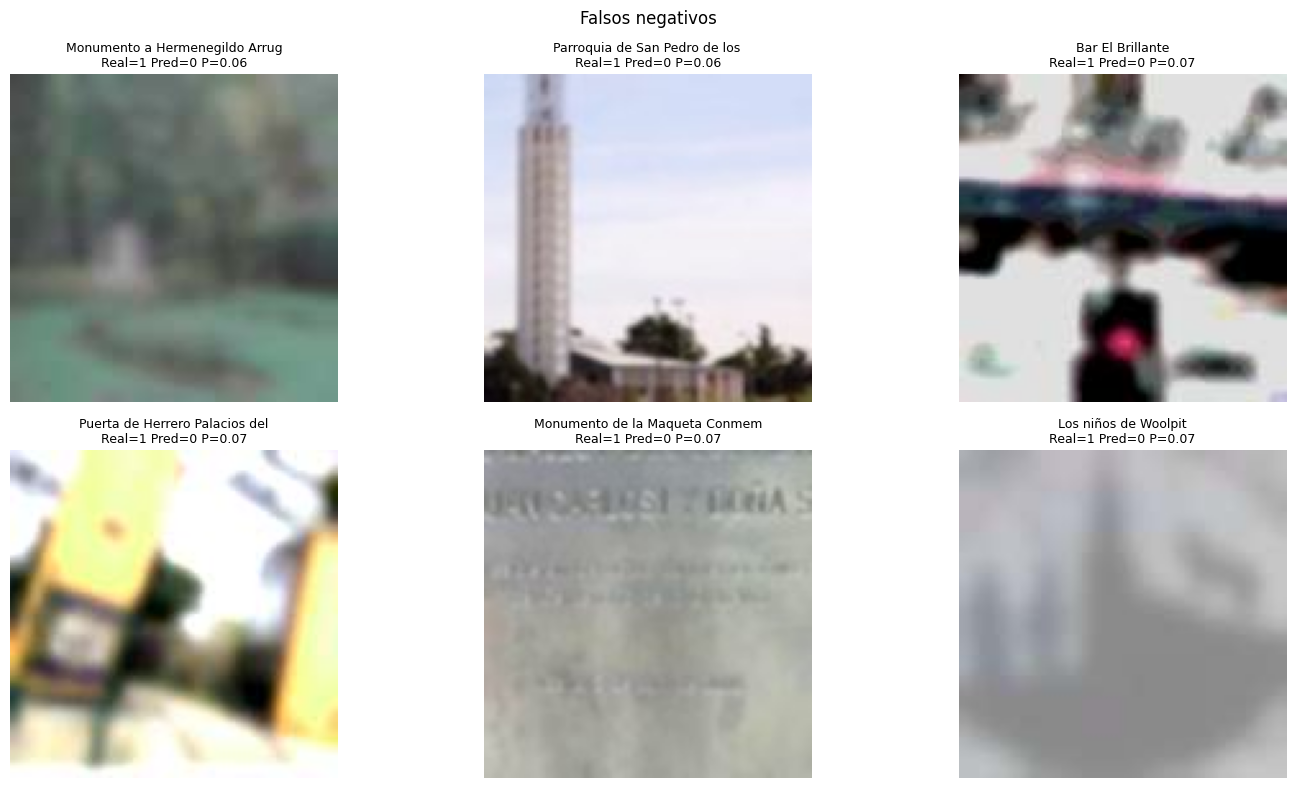

In [19]:
# ============================================================
# 12. Análisis de falsos positivos y falsos negativos


results_df = test_df.copy()
results_df["y_true"] = y_true
results_df["y_pred"] = y_pred
results_df["prob_engagement_alto"] = y_proba

false_positives = results_df[(results_df["y_true"] == 0) & (results_df["y_pred"] == 1)].sort_values(
    "prob_engagement_alto", ascending=False
)

false_negatives = results_df[(results_df["y_true"] == 1) & (results_df["y_pred"] == 0)].sort_values(
    "prob_engagement_alto", ascending=True
)

print("Falsos positivos:", len(false_positives))
print("Falsos negativos:", len(false_negatives))

display(results_df[[
    "id", "name", "engagement_score", "y_true", "y_pred", "prob_engagement_alto"
]].head())


def show_error_examples(error_df, title, n=6):
    if len(error_df) == 0:
        print(f"No hay ejemplos para: {title}")
        return

    sample = error_df.head(n)
    cols = min(3, len(sample))
    rows = int(np.ceil(len(sample) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["image_path_abs"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"{row['name'][:30]}\nReal={row['y_true']} Pred={row['y_pred']} P={row['prob_engagement_alto']:.2f}",
            fontsize=9
        )
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_error_examples(false_positives, "Falsos positivos")
show_error_examples(false_negatives, "Falsos negativos")

## 13. Guardado de modelo, preprocesadores y resultados

Se guardarán:

- Mejor modelo: **outputs/best_model.keras**
- Modelo final: **outputs/final_model.keras**
- Preprocesador tabular: **outputs/preprocessor.joblib**
- Predicciones de test: **outputs/test_predictions.csv**
- Métricas: **outputs/metrics_summary.csv**

Estos archivos forman parte de los entregables del proyecto.

In [20]:
# ============================================================
# 13. Guardado de artefactos


model.save(OUTPUT_DIR / "final_model.keras")

preprocessor_to_save = {
    "preprocessor": preprocessor,
    "tabular_feature_names": tabular_feature_names,
    "engagement_threshold": engagement_threshold,
    "engagement_formula": "0.50*Likes_scaled + 0.30*Bookmarks_scaled + 0.10*Visits_scaled - 0.10*Dislikes_scaled",
    "img_size": IMG_SIZE,
    "seed": SEED,
}

joblib.dump(preprocessor_to_save, OUTPUT_DIR / "preprocessor.joblib")

predictions_to_save = results_df[[
    "id", "name", "engagement_score", "engagement_label",
    "y_true", "y_pred", "prob_engagement_alto", "main_image_path"
]].copy()

predictions_to_save.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

pd.DataFrame([metrics_summary]).to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

print("Archivos guardados en:", OUTPUT_DIR)
print(list(OUTPUT_DIR.iterdir()))

Archivos guardados en: /content/outputs
[PosixPath('/content/outputs/best_model.keras'), PosixPath('/content/outputs/test_predictions.csv'), PosixPath('/content/outputs/preprocessor.joblib'), PosixPath('/content/outputs/final_model.keras'), PosixPath('/content/outputs/metrics_summary.csv'), PosixPath('/content/outputs/training_history.csv')]


## 14. Qué se ha hecho

Se ha desarrollado un modelo multimodal para predecir el nivel de engagement de POIs turísticos combinando imágenes y metadatos.  
La variable objetivo se ha construido a partir de likes, bookmarks, visits y dislikes.

### Decisiones importantes

- Se han agregado POIs duplicados por `id` para evitar data leakage.
- Las métricas de engagement no se han usado como entrada del modelo.
- El modelo combina una CNN para imágenes con una red densa para metadatos.
- Se ha utilizado `EarlyStopping`, `Dropout` y regularización L2 para reducir overfitting.

### Limitaciones

- El dataset es relativamente pequeño para entrenar una CNN desde cero.
- La variable objetivo es una aproximación construida manualmente.
- Los tags tienen alta cardinalidad, por lo que solo se usan los más frecuentes.
